# Outfit Graph — Qualitative Inspection

Notebook để kiểm tra graph chất lượng outfit pairing bằng cách hiển thị ảnh thật của anchor + neighbors. Mỗi cell tự rerun-able — chạy lại để có sample mới.

**Mục tiêu**: với mỗi anchor (1 item bất kỳ), top-K neighbors trong graph có hợp lý không?
- Đa dạng product_type (áo → quần/giày/áo khoác chứ không phải áo → áo).
- Color compatible (theo legacy filter: neutral/tonal/cross-earth/etc.).
- Không cross-season conflict (winter ↔ summer).

Graph hiện tại: [data/processed/final_outfit_graph.csv](../data/processed/final_outfit_graph.csv) (cobuy_full_legacy, 38K nodes, 699K edges).

## Setup

Chỉ chạy 1 lần. Load catalog + graph + define viewer class.

In [1]:
import os
import random
import sys
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.backend.core.config import settings
from src.backend.services.catalog import FashionCatalog

catalog = FashionCatalog(settings.meta_file, settings.graph_file, settings.image_dir)
print(f"meta articles: {len(catalog.meta_by_article):,}")
print(f"graph nodes:   {len(catalog.graph_adj):,}")
print(f"image dir:     {settings.image_dir}")

meta articles: 70,197
graph nodes:   38,276
image dir:     D:\mRAG_repo\data\raw\images


In [2]:
class GraphViewer:
    def __init__(self, catalog: FashionCatalog, image_dir: str):
        self.catalog = catalog
        self.image_dir = image_dir

    def load_image(self, article_id: str) -> Optional[Image.Image]:
        path = self.catalog.article_image_path(article_id)
        if not os.path.exists(path):
            return None
        try:
            img = Image.open(path).convert("RGB")
            img.thumbnail((400, 600))
            return img
        except Exception:
            return None

    def label_for(self, article_id: str, weight: Optional[float] = None) -> str:
        meta = self.catalog.get_meta(article_id)
        pt = meta.get("product_type_name", "?")
        color = meta.get("colour_group_name", "?")
        fit = meta.get("fit", "")
        base = f"{pt}\n{color}"
        if fit:
            base += f" | {fit}"
        if weight is not None:
            base += f"\nw={weight:.0f}"
        return base

    def _draw_tile(self, ax, article_id: str, weight: Optional[float], is_anchor: bool):
        img = self.load_image(article_id)
        if img is None:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, f"no img\n{article_id}", ha="center", va="center", color="white", fontsize=8)
        else:
            ax.imshow(img)
        title = self.label_for(article_id, weight=weight)
        if is_anchor:
            ax.set_title(f"ANCHOR #{article_id}\n{title}", fontsize=9, color="crimson", fontweight="bold")
        else:
            ax.set_title(f"#{article_id}\n{title}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("crimson" if is_anchor else "#888")
            spine.set_linewidth(3 if is_anchor else 1)

    def render_anchor_neighbors(self, anchor_id: str, top_k: int = 8, cols: int = 5, figsize_scale: float = 2.4) -> None:
        neighbors = self.catalog.graph_adj.get(anchor_id, [])
        if not neighbors:
            print(f"anchor #{anchor_id} không có neighbor trong graph")
            return
        items: List[Tuple[str, Optional[float], bool]] = [(anchor_id, None, True)]
        for nid, weight in neighbors[:top_k]:
            items.append((nid, float(weight), False))
        total = len(items)
        rows = (total + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_scale, rows * figsize_scale * 1.4))
        axes = np.atleast_2d(axes).reshape(rows, cols)
        for idx, (aid, weight, is_anchor) in enumerate(items):
            r, c = divmod(idx, cols)
            self._draw_tile(axes[r, c], aid, weight, is_anchor)
        for idx in range(total, rows * cols):
            r, c = divmod(idx, cols)
            axes[r, c].axis("off")
        plt.tight_layout()
        plt.show()

    def render_random_batch(self, n_anchors: int = 4, top_k: int = 5, seed: Optional[int] = None, only_with_image: bool = True) -> List[str]:
        rng = random.Random(seed) if seed is not None else random.Random()
        all_nodes = list(self.catalog.graph_adj.keys())
        rng.shuffle(all_nodes)
        picked: List[str] = []
        for node in all_nodes:
            if only_with_image and not os.path.exists(self.catalog.article_image_path(node)):
                continue
            picked.append(node)
            if len(picked) >= n_anchors:
                break
        if not picked:
            print("không tìm được anchor nào có ảnh")
            return []

        cols = top_k + 1
        fig, axes = plt.subplots(len(picked), cols, figsize=(cols * 2.4, len(picked) * 2.8))
        axes = np.atleast_2d(axes).reshape(len(picked), cols)
        for r, anchor_id in enumerate(picked):
            neighbors = self.catalog.graph_adj.get(anchor_id, [])[:top_k]
            self._draw_tile(axes[r, 0], anchor_id, None, is_anchor=True)
            for c in range(1, cols):
                if c - 1 < len(neighbors):
                    nid, weight = neighbors[c - 1]
                    self._draw_tile(axes[r, c], nid, float(weight), is_anchor=False)
                else:
                    axes[r, c].axis("off")
        plt.tight_layout()
        plt.show()
        return picked

    def render_multihop(self, anchor_id: str, max_hops: int = 2, branch_per_hop: int = 3, limit: int = 8, cols: int = 5) -> None:
        ids = self.catalog.get_graph_multihop_outfit_ids(
            anchor_id,
            max_hops=max_hops,
            branch_per_hop=branch_per_hop,
            preferred_min_weight=settings.graph_preferred_min_weight,
            hard_min_weight=settings.graph_hard_min_weight,
            limit=limit,
        )
        if not ids:
            print(f"anchor #{anchor_id} không sinh được multihop outfit")
            return
        items = [(anchor_id, None, True)] + [(nid, None, False) for nid in ids]
        total = len(items)
        rows = (total + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 3.2))
        axes = np.atleast_2d(axes).reshape(rows, cols)
        for idx, (aid, weight, is_anchor) in enumerate(items):
            r, c = divmod(idx, cols)
            self._draw_tile(axes[r, c], aid, weight, is_anchor)
        for idx in range(total, rows * cols):
            r, c = divmod(idx, cols)
            axes[r, c].axis("off")
        plt.tight_layout()
        plt.show()


viewer = GraphViewer(catalog, settings.image_dir)

## Section 1 — Anchor cố định + top-K neighbors

Đặt `ANCHOR_ID` để kiểm tra một item cụ thể. `TOP_K` = số neighbors hiển thị.

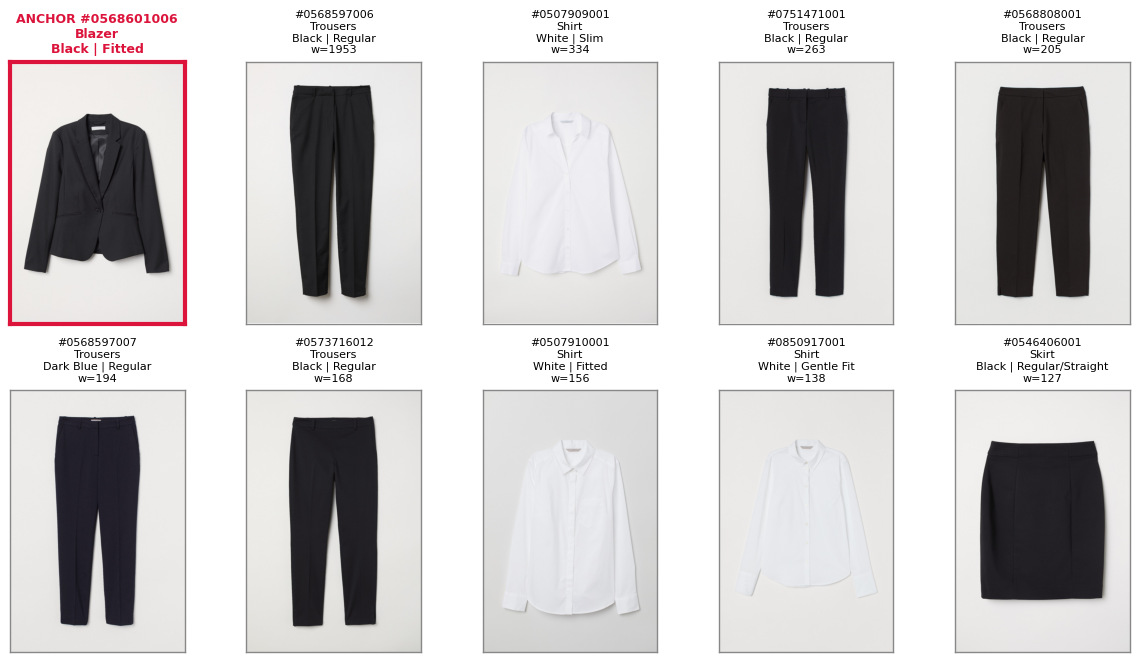

In [3]:
ANCHOR_ID = "0568601006"  # Blazer Black — đổi sang bất kỳ article_id 10-digit nào trong graph
TOP_K = 9
COLS = 5

viewer.render_anchor_neighbors(ANCHOR_ID, top_k=TOP_K, cols=COLS)

## Section 2 — Multi-hop outfit cho anchor đó

Mô phỏng `get_graph_multihop_outfit_ids` của catalog.py — hàm thật được endpoint `/api/chat` gọi khi intent = `graph_pairing`.

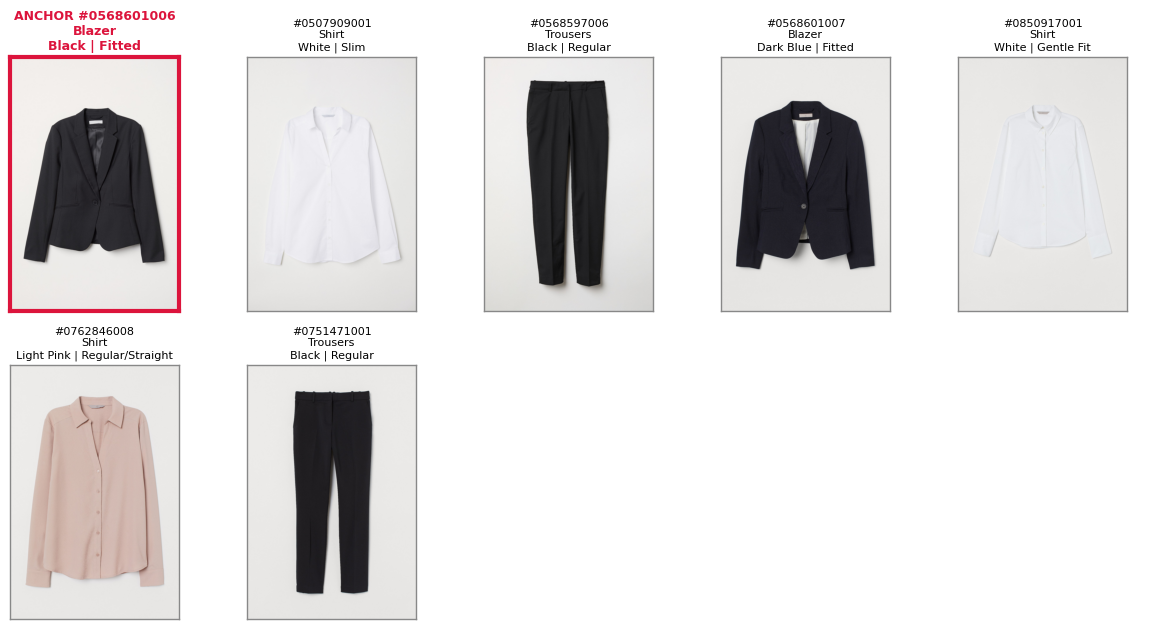

In [4]:
MAX_HOPS = 2
BRANCH_PER_HOP = 3
LIMIT = 8

viewer.render_multihop(ANCHOR_ID, max_hops=MAX_HOPS, branch_per_hop=BRANCH_PER_HOP, limit=LIMIT, cols=5)

## Section 3 — Random batch sampling

**Rerun cell này để có sample mới** (không fix seed). Mỗi rerun pick `N_ANCHORS` items ngẫu nhiên có ảnh, hiển thị mỗi item kèm top-K neighbors trên một row.

Để fix sample dùng cho thesis figure: đặt `SEED = <số nguyên>`.

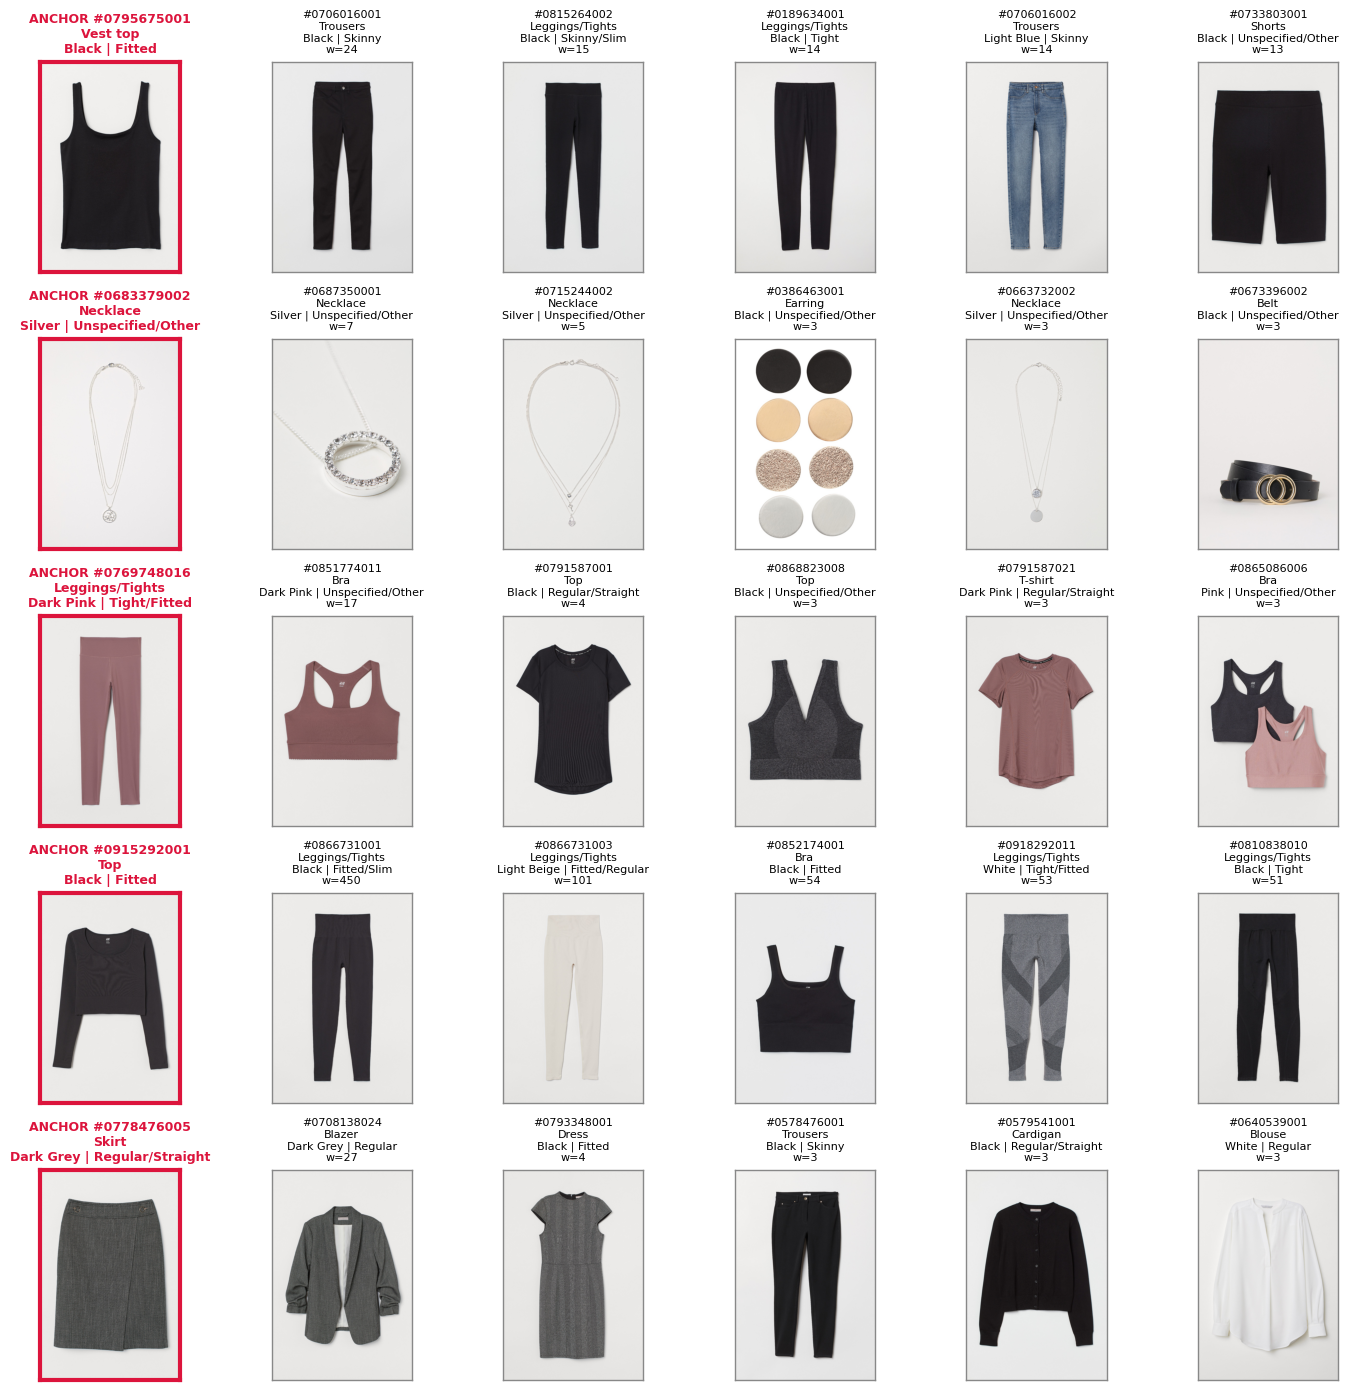

sampled anchors: ['0795675001', '0683379002', '0769748016', '0915292001', '0778476005']


In [5]:
N_ANCHORS = 5
TOP_K_BATCH = 5
SEED = None  # None = random mỗi rerun, hoặc đặt int để fix sample

picked = viewer.render_random_batch(n_anchors=N_ANCHORS, top_k=TOP_K_BATCH, seed=SEED, only_with_image=True)
print("sampled anchors:", picked)

## Section 4 — Stats nhanh của neighbors sample

Pick `N` random anchors, gom tất cả neighbors, đếm phân bố product_type và colour_group. Để check graph có bias về 1 product_type (vd. Trousers dominate) hay không.

sampled 500 anchors, top-10 neighbors each
avg neighbors / anchor: 6.54 (min=1, max=10)


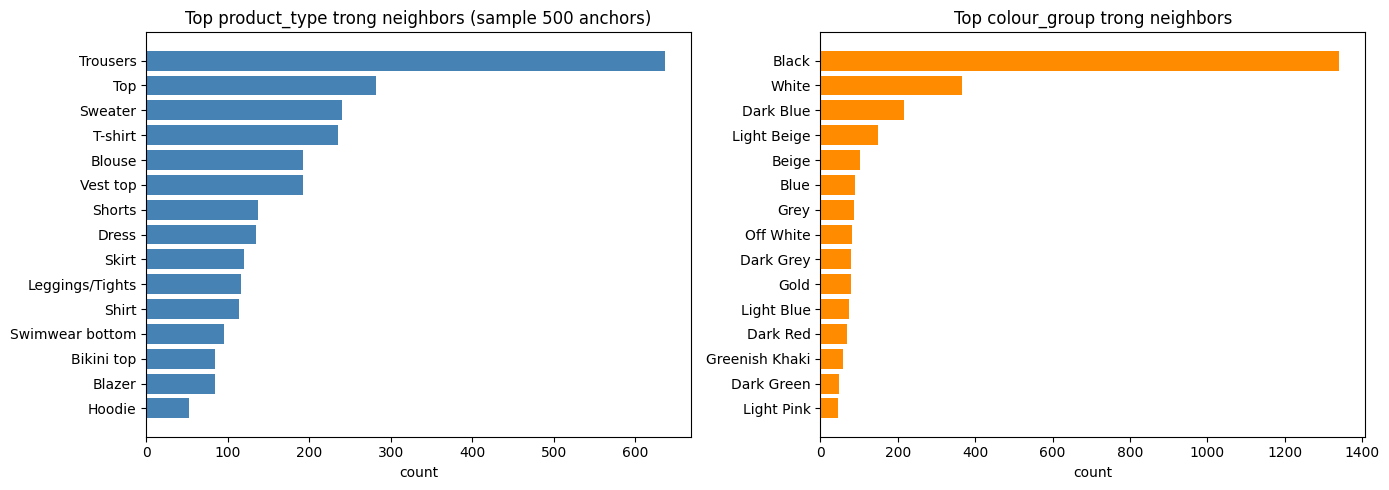

In [6]:
N_SAMPLE = 500
TOP_K_FOR_STATS = 10
SEED_STATS = None

rng = random.Random(SEED_STATS) if SEED_STATS is not None else random.Random()
all_nodes = list(catalog.graph_adj.keys())
rng.shuffle(all_nodes)
sample_anchors = all_nodes[:N_SAMPLE]

pt_counter: Counter = Counter()
color_counter: Counter = Counter()
neighbor_count: List[int] = []
for anchor in sample_anchors:
    neighbors = catalog.graph_adj.get(anchor, [])[:TOP_K_FOR_STATS]
    neighbor_count.append(len(neighbors))
    for nid, _ in neighbors:
        meta = catalog.get_meta(nid)
        pt_counter[meta.get("product_type_name", "?")] += 1
        color_counter[meta.get("colour_group_name", "?")] += 1

print(f"sampled {N_SAMPLE} anchors, top-{TOP_K_FOR_STATS} neighbors each")
print(f"avg neighbors / anchor: {np.mean(neighbor_count):.2f} (min={min(neighbor_count)}, max={max(neighbor_count)})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pt_top = pt_counter.most_common(15)
axes[0].barh([x[0] for x in pt_top][::-1], [x[1] for x in pt_top][::-1], color="steelblue")
axes[0].set_title(f"Top product_type trong neighbors (sample {N_SAMPLE} anchors)")
axes[0].set_xlabel("count")
color_top = color_counter.most_common(15)
axes[1].barh([x[0] for x in color_top][::-1], [x[1] for x in color_top][::-1], color="darkorange")
axes[1].set_title(f"Top colour_group trong neighbors")
axes[1].set_xlabel("count")
plt.tight_layout()
plt.show()

## Section 5 — Soi 1 trường hợp cụ thể với meta đầy đủ

Dùng khi muốn debug 1 anchor: in toàn bộ meta của anchor + top-K neighbors + weights ở dạng bảng.

In [7]:
import pandas as pd

DEBUG_ANCHOR = ANCHOR_ID  # hoặc đặt thẳng id khác
DEBUG_TOP_K = 12

anchor_meta = catalog.get_meta(DEBUG_ANCHOR)
print("anchor meta:")
for k, v in anchor_meta.items():
    print(f"  {k}: {v}")
print()

rows = []
for nid, weight in catalog.graph_adj.get(DEBUG_ANCHOR, [])[:DEBUG_TOP_K]:
    m = catalog.get_meta(nid)
    rows.append({
        "article_id": nid,
        "weight": int(weight),
        "product_type": m.get("product_type_name", ""),
        "colour": m.get("colour_group_name", ""),
        "fit": m.get("fit", ""),
        "occasion": m.get("occasion", ""),
        "seasonality": m.get("seasonality", ""),
    })
df_neighbors = pd.DataFrame(rows)
df_neighbors

anchor meta:
  article_id: 0568601006
  product_code: 568601
  product_type_name: Blazer
  colour_group_name: Black
  fit: Fitted
  occasion: Office/Casual
  seasonality: All-Season
  refined_description: A classic black blazer with a tailored fit, featuring notch lapels, jetted front pockets, and decorative buttons at the cuffs. The single back vent adds to its polished look, suitable for both office and casual wear.



,article_id,weight,product_type,colour,fit,occasion,seasonality
0,0568597006,1953,Trousers,Black,Regular,Formal/Work,All-Season
1,0507909001,334,Shirt,White,Slim,Formal/Office,All-Season
2,0751471001,263,Trousers,Black,Regular,Casual/Work,All-Season
3,0568808001,205,Trousers,Black,Regular,Formal/Office,All-Season
4,0568597007,194,Trousers,Dark Blue,Regular,Casual/Work,All-Season
5,0573716012,168,Trousers,Black,Regular,Casual/Work,All-Season
6,0507910001,156,Shirt,White,Fitted,Casual/Office,All-Season
7,0850917001,138,Shirt,White,Gentle Fit,Casual/Office,All-Season
8,0546406001,127,Skirt,Black,Regular/Straight,Business/Casual,All-Season
9,0789772001,123,Shirt,White,Fitted,Casual/Office,All-Season


## Cách dùng cho thesis

- **Section 1 + 2**: chọn 2-3 anchor đại diện (vd. Blazer, Dress, Sneaker), screenshot làm figure trong thesis chapter graph pairing.
- **Section 3 với SEED cố định** (vd. 42, 123): tạo figure ngẫu nhiên reproducible.
- **Section 4**: chứng minh distribution diverse, không bị 1 product_type dominate → graph quality OK.
- **Section 5**: nếu hội đồng hỏi case-by-case, dùng để debug live.